# Cliffwalk environment
## init 
    nrow, ncol, set default position x, y
## step : to change position 
    input : anction from 0-3
    return: nextposition, reward, done
## reset:  return to default position
    return defaultPosition

In [62]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm  # tqdm是显示循环进度条的库
import time as time

In [76]:
  

class CliffWalkingEnv:
    def __init__(self, ncol, nrow):
        self.nrow = nrow
        self.ncol = ncol
        self.y = self.nrow -1
        self.x = 0
    
    def step(self, action):# next position, reward, done
        change = [[0,-1], [0, 1], [-1, 0], [1, 0]]
        # new_x = self.x + change[action][0]
        # new_y = self.y + change[action][1]
        # if new_x >= 0 and new_x < self.ncol and new_y >=0 and new_y < self.nrow:
        #     # print(new_x == min(self.ncol - 1, max(0, self.x + change[action][0])))
        #     # print(new_y == min(self.nrow - 1, max(0, self.y + change[action][1])))
        #     self.x = new_x
        #     self.y = new_y
        self.x = min(self.ncol - 1, max(0, self.x + change[action][0]))
        self.y = min(self.nrow - 1, max(0, self.y + change[action][1]))
        reward = -1
        done = False
        next_state = self.y * self.ncol + self.x
        if self.y == self.nrow -1 and self.x > 0:
            done = True
            if self.x < self.ncol - 1:
                reward = -100
        return next_state, reward, done
    
    def reset(self):
        self.y = self.nrow -1
        self.x = 0
        return self.y * self.ncol + self.x          






# Sara
## init 
    input: self, ncol, nrow, epsilon, alpha, gamma, n_action=4
    init Q_table(Q(s,a))
## take_action:
    epsilon-Greedy
    input: state
    output: action
## update : update Q table
    input: self, s0, a0, r, s1, a

In [77]:
class Sarsa:
    def __init__(self, ncol, nrow, epsilon, alpha, gamma, n_action = 4):
        self.Q_table = np.zeros([ncol * nrow, n_action])
        self.epsilon = epsilon
        self.alpha = alpha
        self.gamma = gamma
        self.n_action = n_action
    
    def take_action(self, state):
        if (np.random.rand() < self.epsilon):
            action = np.random.randint(self.n_action)
        else:
            action = np.argmax(self.Q_table[state])
        return action
    
    def update(self, s0, a0, r, s1, a1):
        self.Q_table[s0, a0] += self.alpha * (r + self.gamma* self.Q_table[s1, a1] - self.Q_table[s0, a0])
        

# Running Sara
    ncol = 12
    nrow = 4
    env = CliffWalkingEnv(ncol, nrow)
    np.random.seed(0)
    epsilon = 0.1
    alpha = 0.1
    gamma = 0.9
    agent = Sarsa(ncol, nrow, epsilon, alpha, gamma) # INIT SARA
    num_episodes = 500  # 智能体在环境中运行的序列的数量 # RUN 500times

iteration 9: 100%|██████████| 50/50 [00:00<00:00, 3851.87it/s, episode=500, return=-18.900]


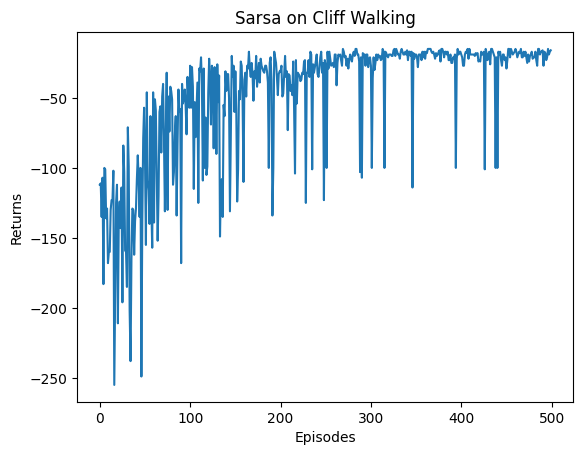

In [78]:
ncol = 12
nrow = 4
env = CliffWalkingEnv(ncol, nrow)
np.random.seed(0)
epsilon = 0.1
alpha = 0.1
gamma = 0.9
agent = Sarsa(ncol, nrow, epsilon, alpha, gamma) # INIT SARA
num_episodes = 500  # 智能体在环境中运行的序列的数量 # RUN 500times

return_list = []# record all return in a sequence
for i in range(10):
    with tqdm(total = int(num_episodes / 10), desc = f'iteration {i}') as pbar:
        for i_episode in range(int(num_episodes / 10)): 
            episode_return = 0
            state = env.reset()
            action = agent.take_action(state)
            done = False
            while not done:
                next_state, reward, done = env.step(action)
                next_action = agent.take_action(next_state)
                episode_return += reward
                agent.update(state, action, reward, next_state, next_action)
                state = next_state
                action = next_action
            return_list.append(episode_return)
            if (i_episode + 1) % 10 == 0:  # 每10条序列打印一下这10条序列的平均回报
                pbar.set_postfix({
                    'episode':
                    '%d' % (num_episodes / 10 * i + i_episode + 1),
                    'return':
                    '%.3f' % np.mean(return_list[-10:])
                })
            pbar.update(1)
            

#print
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Sarsa on {}'.format('Cliff Walking'))
plt.show()

## tqdm Usage


In [79]:
text = ""
for char in tqdm(["a", "b", "c", "d"]):
    text = text + char
    time.sleep(0.5)
print(text)

100%|██████████| 4/4 [00:02<00:00,  1.99it/s]

abcd


In [80]:
pbar = tqdm(["a", "b", "c", "d"])
for char in pbar:
    pbar.set_description("Processing %s" % char)

Processing d: 100%|██████████| 4/4 [00:00<00:00, 976.78it/s]


In [81]:
with tqdm(total=100) as pbar:
    for i in range(10):
        pbar.update(10)
        time.sleep(0.5)

100%|██████████| 100/100 [00:05<00:00, 19.84it/s]


In [82]:
pbar = tqdm(total=100)
for i in range(10):
    pbar.update(10)
pbar.close()

100%|██████████| 100/100 [00:00<00:00, 203705.88it/s]


# Sara with not fixed epsilon

In [83]:
class SarsaDecreasingEpsilon:
    def __init__(self, ncol, nrow, epsilon, alpha, gamma, n_action = 4):
        self.Q_table = np.zeros([ncol * nrow, n_action])
        self.epsilon = epsilon
        self.alpha = alpha
        self.gamma = gamma
        self.n_action = n_action
    
    def take_action(self, state, i = 1):
        if (np.random.rand() < self.epsilon * i):
            action = np.random.randint(self.n_action)
        else:
            action = np.argmax(self.Q_table[state])
        return action
    
    def update(self, s0, a0, r, s1, a1):
        self.Q_table[s0, a0] += self.alpha * (r + self.gamma* self.Q_table[s1, a1] - self.Q_table[s0, a0])

iteration 9: 100%|██████████| 50/50 [00:00<00:00, 9279.84it/s, episode=500, return=-13.000]


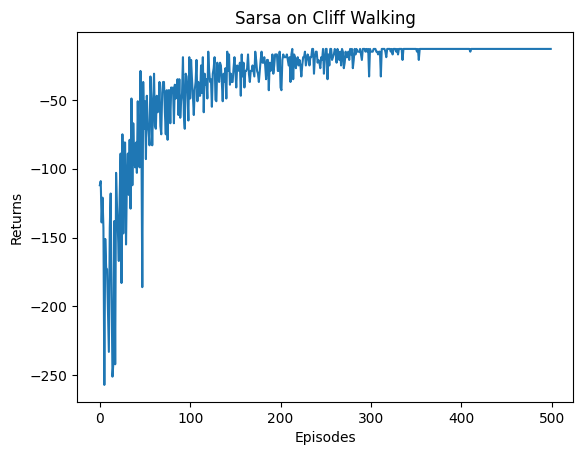

In [94]:
ncol = 12
nrow = 4
env = CliffWalkingEnv(ncol, nrow)
np.random.seed(0)
epsilon = 0.1
alpha = 0.1
gamma = 0.9
agent = SarsaDecreasingEpsilon(ncol, nrow, epsilon, alpha, gamma) # INIT SARA
num_episodes = 500  # 智能体在环境中运行的序列的数量 # RUN 500times

return_list = []# record all return in a sequence
for i in range(10):
    with tqdm(total = int(num_episodes / 10), desc = f'iteration {i}') as pbar:
        for i_episode in range(int(num_episodes / 10)): 
            episode_return = 0
            state = env.reset()            
            done = False
            rate = 1 / (num_episodes / 10 * i + i_episode + 1)
            action = agent.take_action(state, rate)
            while not done:
                next_state, reward, done = env.step(action)
                next_action = agent.take_action(next_state, rate)
                episode_return += reward
                agent.update(state, action, reward, next_state, next_action)
                state = next_state
                action = next_action
            return_list.append(episode_return)
            if (i_episode + 1) % 10 == 0:  # 每10条序列打印一下这10条序列的平均回报
                pbar.set_postfix({
                    'episode':
                    '%d' % (num_episodes / 10 * i + i_episode + 1),
                    'return':
                    '%.3f' % np.mean(return_list[-10:])
                })
            pbar.update(1)
            

#print
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Sarsa on {}'.format('Cliff Walking'))
plt.show()

# n-step Sarsa
## init :
    input: self, n, ncol, nrow, epsilon, alpha, gamma, n_action=4 (n:step)
    create Q-table,
    self.state_list = []  # 保存之前的状态
    self.action_list = []  # 保存之前的动作
    self.reward_list = []  # 保存之前的奖励
## take_action:epsilon greedy
    input:state
    output:action
## update
    input: s0,a0,r,s1,a1
    update Q-table

In [85]:
class nstep_Sarsa:
    def __init__(self, n, ncol, nrow, epsilon, alpha, gamma, n_action = 4):
        self.Q_table = np.zeros([ncol * nrow, n_action])
        self.n = n
        self.ncol = ncol
        self.nrow = nrow
        self.epsilon = epsilon
        self.alpha = alpha
        self.gamma = gamma
        self.n_action = n_action
        self.state_list = []
        self.action_list = []
        self.reward_list = []
    
    def take_action(self, state):
        if np.random.random() < self.epsilon:
            action = np.random.randint(self.n_action)
        else:
            action = np.argmax(self.Q_table[state])
        return action
    
    def update(self, s0, a0, r, s1, a1, done):
        self.state_list.append(s0)
        self.action_list.append(a0)
        self.reward_list.append(r)
        if len(self.state_list) == self.n:
            G = self.Q_table[s1, a1]
            for i in reversed(range(self.n)):
                G = self.gamma * G + self.reward_list[i]
                if done and i > 0:
                    s = self.state_list[i]
                    a = self.action_list[i]
                    self.Q_table[s, a] += self.alpha * (G - self.Q_table[s,a])
            a = self.action_list.pop(0)
            s = self.state_list.pop(0)
            self.reward_list.pop(0)

            self.Q_table[s, a] += self.alpha * (G - self.Q_table[s, a])
        if done:
            self.state_list = []
            self.action_list = []
            self.reward_list = []

Iteration 9:  98%|█████████▊| 49/50 [00:00<00:00, 6486.17it/s, episode=500, return=-19.100]

Iteration 9: 100%|██████████| 50/50 [00:00<00:00, 6335.04it/s, episode=500, return=-19.100]


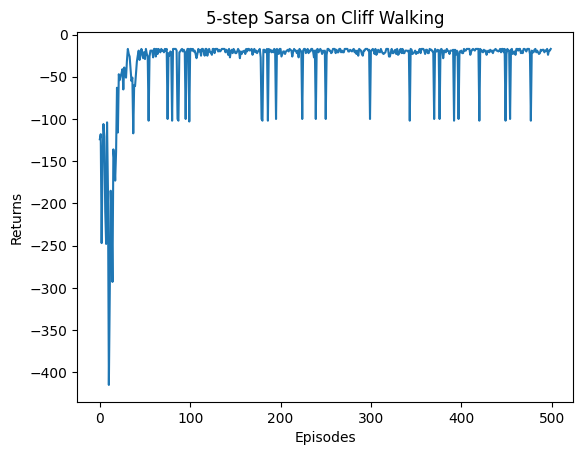

In [86]:
ncol = 12
nrow = 4
env = CliffWalkingEnv(ncol, nrow)
np.random.seed(0)
n_step = 5  # 5步Sarsa算法
alpha = 0.1
epsilon = 0.1
gamma = 0.9
agent = nstep_Sarsa(n_step, ncol, nrow, epsilon, alpha, gamma)
num_episodes = 500  # 智能体在环境中运行的序列的数量

return_list = []  # 记录每一条序列的回报
for i in range(10):  # 显示10个进度条
    #tqdm的进度条功能
    with tqdm(total=int(num_episodes / 10), desc='Iteration %d' % i) as pbar:
        for i_episode in range(int(num_episodes / 10)):  # 每个进度条的序列数
            episode_return = 0
            state = env.reset()
            action = agent.take_action(state)
            done = False
            while not done:
                next_state, reward, done = env.step(action)
                next_action = agent.take_action(next_state)
                episode_return += reward  # 这里回报的计算不进行折扣因子衰减
                agent.update(state, action, reward, next_state, next_action,
                             done)
                state = next_state
                action = next_action
            return_list.append(episode_return)
            if (i_episode + 1) % 10 == 0:  # 每10条序列打印一下这10条序列的平均回报
                pbar.set_postfix({
                    'episode':
                    '%d' % (num_episodes / 10 * i + i_episode + 1),
                    'return':
                    '%.3f' % np.mean(return_list[-10:])
                })
            pbar.update(1)

episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('5-step Sarsa on {}'.format('Cliff Walking'))
plt.show()

# nStep Sara with decreasing Epsilon

In [91]:
class nstep_Sarsa_De:
    def __init__(self, n, ncol, nrow, epsilon, alpha, gamma, n_action = 4):
        self.Q_table = np.zeros([ncol * nrow, n_action])
        self.n = n
        self.ncol = ncol
        self.nrow = nrow
        self.epsilon = epsilon
        self.alpha = alpha
        self.gamma = gamma
        self.n_action = n_action
        self.state_list = []
        self.action_list = []
        self.reward_list = []
    
    def take_action(self, state, i = 1):
        if np.random.random() < self.epsilon * i:
            action = np.random.randint(self.n_action)
        else:
            action = np.argmax(self.Q_table[state])
        return action
    
    def update(self, s0, a0, r, s1, a1, done):
        self.state_list.append(s0)
        self.action_list.append(a0)
        self.reward_list.append(r)
        if len(self.state_list) == self.n:
            G = self.Q_table[s1, a1]
            for i in reversed(range(self.n)):
                G = self.gamma * G + self.reward_list[i]
                if done and i > 0:
                    s = self.state_list[i]
                    a = self.action_list[i]
                    self.Q_table[s, a] += self.alpha * (G - self.Q_table[s,a])
            a = self.action_list.pop(0)
            s = self.state_list.pop(0)
            self.reward_list.pop(0)

            self.Q_table[s, a] += self.alpha * (G - self.Q_table[s, a])
        if done:
            self.state_list = []
            self.action_list = []
            self.reward_list = []

Iteration 9: 100%|██████████| 50/50 [00:00<00:00, 3802.84it/s, episode=500, return=-19.000]


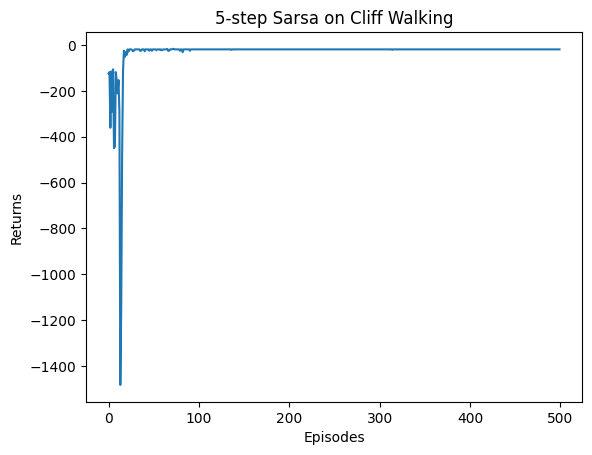

In [92]:
ncol = 12
nrow = 4
env = CliffWalkingEnv(ncol, nrow)
np.random.seed(0)
n_step = 5  # 5步Sarsa算法
alpha = 0.1
epsilon = 0.1
gamma = 0.9
agent = nstep_Sarsa_De(n_step, ncol, nrow, epsilon, alpha, gamma)
num_episodes = 500  # 智能体在环境中运行的序列的数量

return_list = []  # 记录每一条序列的回报
for i in range(10):  # 显示10个进度条
    #tqdm的进度条功能
    with tqdm(total=int(num_episodes / 10), desc='Iteration %d' % i) as pbar:
        for i_episode in range(int(num_episodes / 10)):  # 每个进度条的序列数
            episode_return = 0
            state = env.reset()
            rate = 1 / (num_episodes / 10 * i + i_episode + 1)
            action = agent.take_action(state, rate)
            done = False
            while not done:
                next_state, reward, done = env.step(action)
                next_action = agent.take_action(next_state, rate)
                episode_return += reward  # 这里回报的计算不进行折扣因子衰减
                agent.update(state, action, reward, next_state, next_action, done)
                state = next_state
                action = next_action
            return_list.append(episode_return)
            if (i_episode + 1) % 10 == 0:  # 每10条序列打印一下这10条序列的平均回报
                pbar.set_postfix({
                    'episode':
                    '%d' % (num_episodes / 10 * i + i_episode + 1),
                    'return':
                    '%.3f' % np.mean(return_list[-10:])
                })
            pbar.update(1)

episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('5-step Sarsa on {}'.format('Cliff Walking'))
plt.show()